In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [5]:
data_path = Path("../data/heart_disease.csv")
df = pd.read_csv(data_path)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [6]:
df.shape

(303, 14)

In [7]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [10]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [12]:
df[df["ca"].isnull() | df["thal"].isnull()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,1
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


In [13]:
print("CA value counts:")
print(df["ca"].value_counts(dropna=False).sort_index())

print("\nTHAL value counts:")
print(df["thal"].value_counts(dropna=False).sort_index())

CA value counts:
ca
0.0    176
1.0     65
2.0     38
3.0     20
NaN      4
Name: count, dtype: int64

THAL value counts:
thal
3.0    166
6.0     18
7.0    117
NaN      2
Name: count, dtype: int64


In [14]:
print("Median of ca:", df["ca"].median())
print("Median of thal:", df["thal"].median())

Median of ca: 0.0
Median of thal: 3.0


In [15]:
df_clean = df.copy()

In [16]:
df_clean["ca"] = df_clean["ca"].fillna(df_clean["ca"].median())
df_clean["thal"] = df_clean["thal"].fillna(df_clean["thal"].median())

In [17]:
df_clean.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [18]:
print("Original shape:", df.shape)
print("Cleaned shape :", df_clean.shape)

Original shape: (303, 14)
Cleaned shape : (303, 14)


In [19]:
cleaned_path = Path("../data/heart_disease_cleaned.csv")

df_clean.to_csv(cleaned_path, index=False)

print(f"Saved cleaned dataset to: {cleaned_path}")

Saved cleaned dataset to: ..\data\heart_disease_cleaned.csv


In [20]:
target_counts = df_clean["target"].value_counts().sort_index()

print("No Heart Disease (0):", target_counts[0])
print("Heart Disease (1):", target_counts[1])

No Heart Disease (0): 164
Heart Disease (1): 139


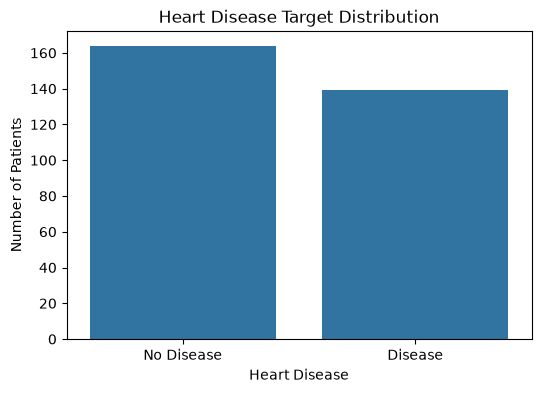

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_clean,
    x="target"
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

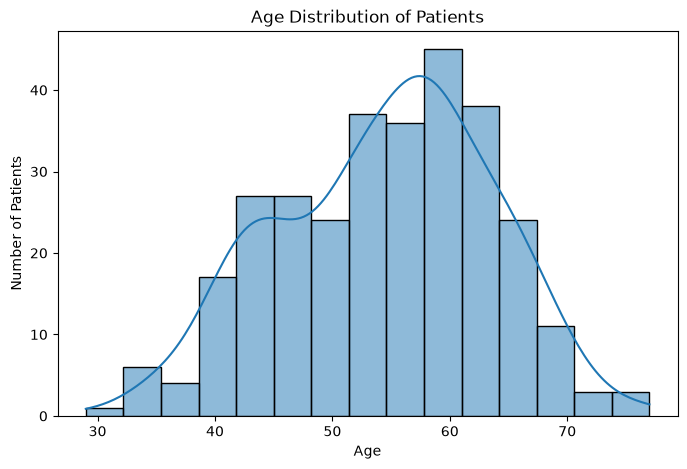

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=15,
    kde=True
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

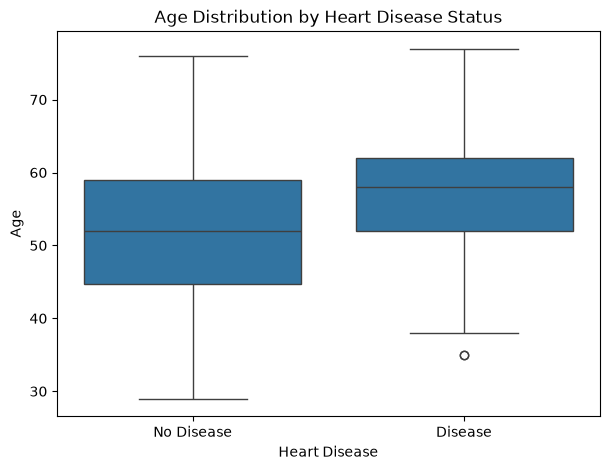

In [25]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="target",
    y="age"
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

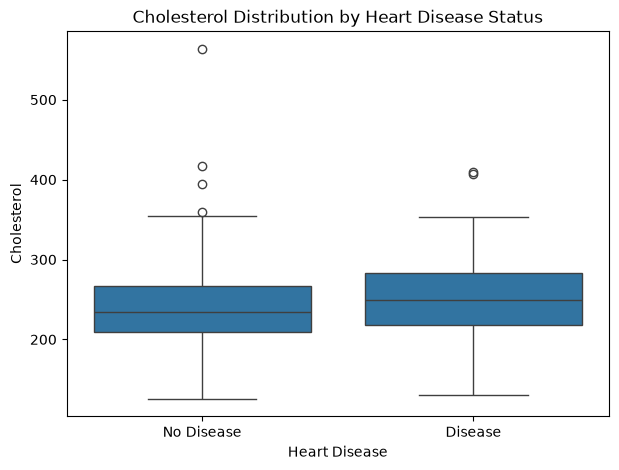

In [26]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="target",
    y="chol"
)

plt.title("Cholesterol Distribution by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")

plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

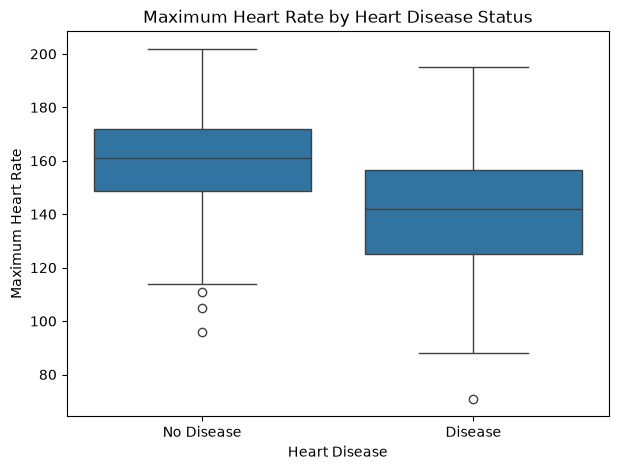

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="target",
    y="thalach"
)

plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")

plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

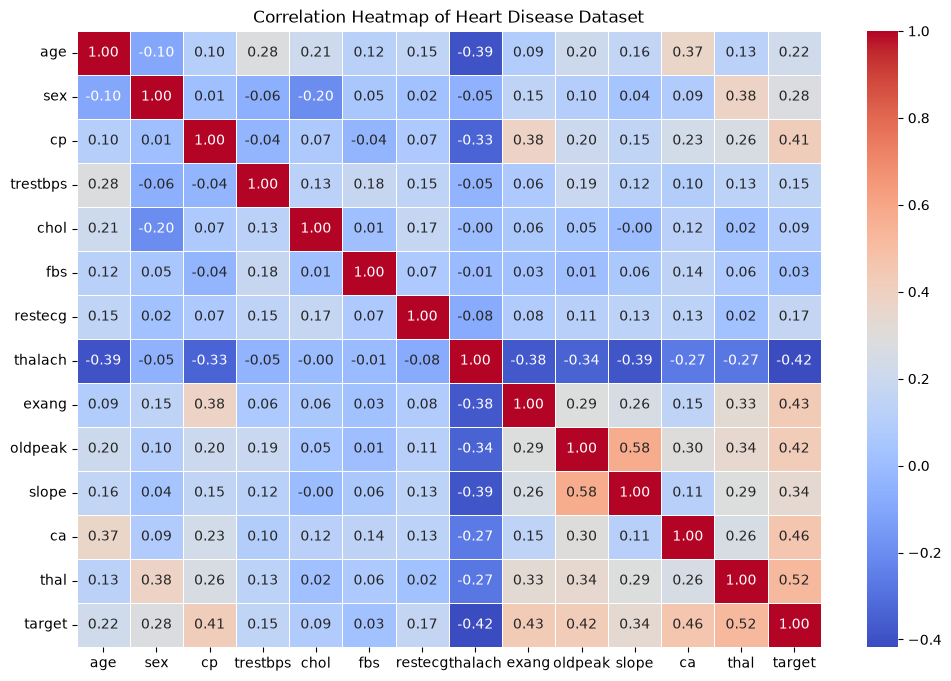

In [28]:
plt.figure(figsize=(12, 8))

correlation = df_clean.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Heart Disease Dataset")

plt.show()

In [29]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [30]:
for column in df_clean.columns:
    print(f"\n{column}:")
    print(sorted(df_clean[column].unique()))


age:
[np.float64(29.0), np.float64(34.0), np.float64(35.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(54.0), np.float64(55.0), np.float64(56.0), np.float64(57.0), np.float64(58.0), np.float64(59.0), np.float64(60.0), np.float64(61.0), np.float64(62.0), np.float64(63.0), np.float64(64.0), np.float64(65.0), np.float64(66.0), np.float64(67.0), np.float64(68.0), np.float64(69.0), np.float64(70.0), np.float64(71.0), np.float64(74.0), np.float64(76.0), np.float64(77.0)]

sex:
[np.float64(0.0), np.float64(1.0)]

cp:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

trestbps:
[np.float64(94.0), np.float64(100.0), np.float64(101.0), np.float64(102.0), np.float64(104.0), np.float64(105.0), np.float64(106.

In [31]:
df_clean.groupby("target")[[
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]].mean()

,age,trestbps,chol,thalach,oldpeak
target,,,,,
0,52.585366,129.250000,242.640244,158.378049,0.586585
1,56.625899,134.568345,251.474820,139.258993,1.574101


In [32]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 242
Testing samples : 61


In [34]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [36]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [38]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [39]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}") 

Model Performance
-----------------
Accuracy : 0.8852
Precision: 0.8387
Recall   : 0.9286
F1 Score : 0.8814


In [41]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Disease", "Disease"]
))

              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



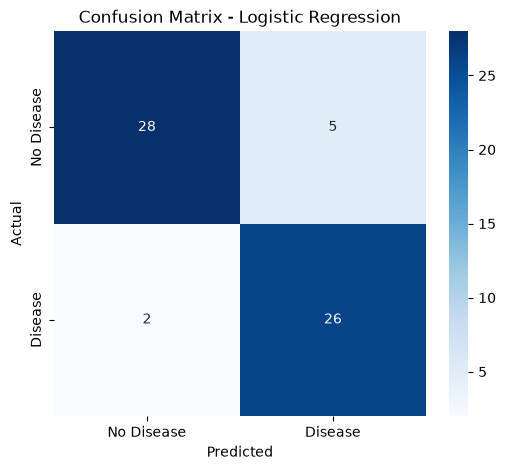

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}") 

Model Performance
-----------------
Accuracy : 0.8852
Precision: 0.8387
Recall   : 0.9286
F1 Score : 0.8814


In [43]:
import joblib

model_path = "../model/heart_disease_model.pkl"

joblib.dump(model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../model/heart_disease_model.pkl


In [45]:
import os

print(os.path.exists("../model/heart_disease_model.pkl"))

True


In [46]:
# Validate the saved model

import joblib
import pandas as pd

loaded_model = joblib.load("../model/heart_disease_model.pkl")

test_patient = pd.DataFrame({
    "age": [65],
    "sex": [1],
    "cp": [4],
    "trestbps": [150],
    "chol": [280],
    "fbs": [0],
    "restecg": [0],
    "thalach": [110],
    "exang": [1],
    "oldpeak": [2.5],
    "slope": [2],
    "ca": [2],
    "thal": [7]
})

prediction = loaded_model.predict(test_patient)[0]
probability = loaded_model.predict_proba(test_patient)[0][1]

print("Prediction:", prediction)
print(f"Probability: {probability * 100:.2f}%")

Prediction: 1
Probability: 99.53%
